In [36]:
from river import stream 
from river import datasets
from river import tree, ensemble, forest
from river import metrics
from river import compose, preprocessing, linear_model
from river import feature_extraction
from river import drift
from itertools import islice
from river import base
import matplotlib as plt
metric = metrics.MSE() 
import itertools
from tqdm import tqdm
import geopandas as gpd
from shapely.geometry import Point
import warnings
from geopy.distance import geodesic
import numpy as np
from collections import defaultdict,deque
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
# Na calym datasecie
# Manhattan        921379
# Queens            58774
# Brooklyn          18071
# Bronx               877
# NaN                 855
# Staten Island        44

In [3]:
#%pip install geopandas shapely pyproj pyogrio --no-cache-dir

In [4]:
#%pip install geopy

In [5]:
data=datasets.Taxis()
data

Taxi ride durations in New York City.

The goal is to predict the duration of taxi rides in New York City.

References
----------
[^1]: [New York City Taxi Trip Duration competition on Kaggle](https://www.kaggle.com/c/nyc-taxi-trip-duration)

      Name  Taxis                                                    
      Task  Regression                                               
   Samples  1,458,644                                                
  Features  8                                                        
    Sparse  False                                                    
      Path  /root/river_data/Taxis/train.csv                         
       URL  https://maxhalford.github.io/files/datasets/nyc_taxis.zip
      Size  186.23 MiB                                               
Downloaded  True                                                     

In [6]:
x, y = next(iter(data))
x

{'vendor_id': '2',
 'pickup_datetime': datetime.datetime(2016, 1, 1, 0, 0, 17),
 'passenger_count': 5,
 'pickup_longitude': -73.98174285888672,
 'pickup_latitude': 40.71915817260742,
 'dropoff_longitude': -73.93882751464845,
 'dropoff_latitude': 40.82918167114258,
 'store_and_fwd_flag': 'N'}

In [7]:
class FeatureDistrict(base.Transformer):
    
    def __init__(self):
        nyc_boroughs = gpd.read_file("nybb.shp")
        nyc_boroughs = nyc_boroughs.to_crs(epsg=4326)

        self.boroughs_list = [
            (row['geometry'], row['BoroName']) 
            for i, row in nyc_boroughs.iterrows()
        ]

    def which_dist(self, lat, lon):
        punkt = Point(lon, lat)
        
        for b_geom, b_name in self.boroughs_list:
            if b_geom.contains(punkt):
                return b_name
        return "Outside_NYC"
    
    def which_dist_2(self, lat, lon): #recznie nieuzywany juz 
        if 40.70 <= lat <= 40.88 and -74.02 <= lon <= -73.91:
            return "Manhattan"
        elif 40.56 <= lat <= 40.74 and -74.04 <= lon <= -73.83:
            return "Brooklyn"
        elif 40.54 <= lat <= 40.80 and -73.96 <= lon <= -73.70:
            return "Queens"
        elif 40.80 <= lat <= 40.92 and -73.93 <= lon <= -73.76:
            return "Bronx"
        else:
            return "Outside_NYC"

    def transform_one(self, x):
        x = x.copy()
        
        dt = x["pickup_datetime"]
        hour = dt.hour
        x["hour"] = hour
        x["day_of_week"] = dt.weekday()
        x["is_weekend"] = int(dt.weekday() >= 5)

        pickup_d = self.which_dist(x["pickup_latitude"], x["pickup_longitude"])
        dropoff_d = self.which_dist(x["dropoff_latitude"], x["dropoff_longitude"])

        x["pickup_district"] = pickup_d
        x["dropoff_district"] = dropoff_d

        x["within_district"] = int(
            pickup_d == dropoff_d and pickup_d != "Outside_NYC" and dropoff_d !="Outside_NYC"
        )
        a = (x["pickup_latitude"], x["pickup_longitude"])
        b = (x["dropoff_latitude"], x["dropoff_longitude"])
        dist = geodesic(a, b).kilometers
        x["distance"] = dist

        #x["store_and_fwd_flag"] = 1 if x["store_and_fwd_flag"] == "Y" else 0

        remove = ["vendor_id", "store_and_fwd_flag", "passenger_count","pickup_datetime",]
        for k in remove:
            x.pop(k, None)

        return x

In [8]:
x, y = next(iter(data))
x

{'vendor_id': '2',
 'pickup_datetime': datetime.datetime(2016, 1, 1, 0, 0, 17),
 'passenger_count': 5,
 'pickup_longitude': -73.98174285888672,
 'pickup_latitude': 40.71915817260742,
 'dropoff_longitude': -73.93882751464845,
 'dropoff_latitude': 40.82918167114258,
 'store_and_fwd_flag': 'N'}

In [9]:
y

849

In [10]:
transformer = FeatureDistrict()
x_2 = transformer.transform_one(x)
x_2

{'pickup_longitude': -73.98174285888672,
 'pickup_latitude': 40.71915817260742,
 'dropoff_longitude': -73.93882751464845,
 'dropoff_latitude': 40.82918167114258,
 'hour': 0,
 'day_of_week': 4,
 'is_weekend': 0,
 'pickup_district': 'Manhattan',
 'dropoff_district': 'Manhattan',
 'within_district': 1,
 'distance': 12.74390022449115}

In [11]:
dt = x["pickup_datetime"]
#dt = datetime.datetime.strptime(dt, "%Y-%m-%d %H:%M:%S")
hour = dt.hour
hour
dt.weekday()

4

In [12]:

def createShadow():
     return forest.ARFRegressor(n_models=12, seed=0)


In [13]:
def models_dist(district):
    #scaler = preprocessing.StandardScaler()
    if district == "Manhattan":
        model = forest.ARFRegressor(n_models=10, seed=0)
    elif district == "Brooklyn":
        model = ensemble.SRPRegressor(n_models=10, seed=0)
    elif district == "Queens":
         model = forest.ARFRegressor(n_models=13, seed=0)
    elif district == "Bronx":
        model = ensemble.SRPRegressor(n_models=13, seed=0)
    elif district == "Global":
        model = forest.ARFRegressor(n_models=10, seed=0)
    elif district == "Staten Island":
        model = forest.ARFRegressor(n_models=10, seed=0)
    return model


districts = ["Manhattan", "Brooklyn", "Queens", "Bronx","Global","Staten Island"]


In [14]:
s=30000 #5 min dla 300000 sample

models = {d: models_dist(d) for d in districts}
shadow_models = {d: None for d in districts}
a=0.01
# warning_detectors = {d: drift.KSWIN(alpha=0.05) for d in districts}
# drift_detectors = {d: drift.KSWIN(alpha=0.001) for d in districts}

warning_detectors = {d: drift.ADWIN(delta=0.001) for d in districts}
drift_detectors = {d: drift.ADWIN(delta=0.005) for d in districts}

plot_data = []
transformer = FeatureDistrict()
stream = data.take(s) 

In [15]:
error_series = {d: [] for d in districts}     
drift_instances = {d: [] for d in districts}  
local_counts = {d: 0 for d in districts}
window_error = {d: [] for d in districts}
window=100
time_series = {d: [] for d in districts}
drift_timestamps = {d: [] for d in districts}
drift_dist_timestamps={d: [] for d in districts}

In [16]:
configs = {
    "Manhattan": {"window_size": 500, "stat_size": 50, "alpha": 0.001},
    "Brooklyn": {"window_size": 100, "stat_size": 30, "alpha": 0.001},
    "Queens": {"window_size": 100, "stat_size": 30, "alpha": 0.001},
    "Global": {"window_size": 300, "stat_size": 20, "alpha": 0.001},

    "Bronx": {"window_size": 10, "stat_size": 5, "alpha": 0.001},
    "Staten Island": {"window_size": 10, "stat_size": 5, "alpha": 0.001},

}

distribution_detectors = {
    d: drift.KSWIN(
        window_size=params["window_size"],
        stat_size=params["stat_size"],
        alpha=params["alpha"]
    )
    for d, params in configs.items()
}

In [17]:
# x, y = next(iter(data))

# timestamp = x["pickup_datetime"]

# x = transformer.transform_one(x)
# if x["within_district"] == 1:
#     district = x["pickup_district"]
# else:
#     district="Global"
# x.pop("pickup_district",None)
# x.pop("pickup_district",None)
# x


In [18]:
centroid_windows = defaultdict(lambda: deque(maxlen=window))
centroid_ref = {}

centroid_adwin = {d: drift.ADWIN(delta=0.001) for d in districts}


In [19]:

window_size = 100  

error_windows = defaultdict(list)
window_rmse_series = defaultdict(lambda: defaultdict(list))
time_series = defaultdict(list)
drift_timestamps = defaultdict(list)

In [20]:
def centroid(X):
    if len(X) == 0:
        return None
    return np.mean(X, axis=0)

In [21]:
def centroid_distance(c1, c2):
    return np.linalg.norm(c1 - c2) #sprawdzic inna Mahalanobis?

In [24]:
centroid_instances={d: [] for d in districts}
centroid_timestamps= {d: [] for d in districts}

In [33]:
s=30000
data_stream = data.take(s)

In [34]:
for x, y in tqdm(data_stream, desc="Done"):
    timestamp = x["pickup_datetime"]
    timestamp = pd.to_datetime(timestamp)
    date = timestamp.date()
    x = transformer.transform_one(x)
    if x["within_district"] == 1:
        district = x["pickup_district"]
    else:
        district="Global"
    x.pop("pickup_district",None)
    x.pop("dropoff_district",None)
    
    model = models[district]
    
    y_pred = model.predict_one(x)
    local_counts[district] += 1
    instanceCount = local_counts[district]
    if y_pred is not None:
        
        # msa=abs(y_pred - y)
        # error =abs(y_pred - y)/(y + 0.01)

        # distribution_detect=distribution_detectors[district]
        # distribution_detect.update(x["dropoff_longitude"])
        
        # warning=warning_detectors[district]
        # drift=drift_detectors[district]
        # warning.update(msa)
        # drift.update(msa)
        
        # error_series[district].append(error)
        # current_window = error_series[district][-window:]
        # current_rolling_mae = sum(current_window) / len(current_window)
        # window_error[district].append(current_rolling_mae)
        # time_series[district].append(timestamp)

        error = (y_pred - y) ** 2
        error_windows[district].append(error)


        if len(error_windows[district]) > window_size:
            error_windows[district].pop(0)

        if len(error_windows[district]) == window_size:
            rmse = np.sqrt(sum(error_windows[district]) / window_size)
            window_rmse_series[district][date].append(rmse)

        if instanceCount > 100:
            # if distribution_detect.drift_detected:
            #     #print(f"DISTRIBUTION SHIFT DRIFT DETECTED in {district} at count:{instanceCount}")
            #     drift_dist_timestamps[district].append(timestamp)
                
            # if warning.drift_detected:
            #     if shadow_models[district] is None:
            #         print(f"WARNING in {district} at count:{instanceCount}")
            #         shadow_models[district] = createShadow()
            #         shadow_models[district].learn_one(x,y)
    
            # if drift.drift_detected:
            #     #print(f"DRIFT DETECTED in {district} at count:{instanceCount}")
            #     drift_instances[district].append(local_counts[district])
            #     drift_timestamps[district].append(timestamp)
            #     if shadow_models[district] is not None:
            #         models[district] = shadow_models[district]
            #         shadow_models[district] = None 
               # else: models[district] = createShadow()

        #Centroid 
            feature_vec = np.array(list(x.values()), dtype=float)
            centroid_windows[district].append(feature_vec)
            
            if len(centroid_windows[district]) > window_size:
                centroid_windows[district].pop(0)
            if len(centroid_windows[district]) == window:
                current_centroid = centroid(centroid_windows[district])
            
                if district not in centroid_ref:
                    centroid_ref[district] = current_centroid
                else:
                    dist = centroid_distance(current_centroid, centroid_ref[district])
                    centroid_adwin[district].update(dist)
            
                    if centroid_adwin[district].drift_detected:
                        print(f"CENTROID DRIFT DETECTED in {district} at {instanceCount}")
                        centroid_instances[district].append(local_counts[district])
                        centroid_timestamps[district].append(timestamp)
            
                    centroid_ref[district] = current_centroid
    




        
    model.learn_one(x, y)
    

Done: 7438it [00:05, 1465.56it/s]

CENTROID DRIFT DETECTED in Manhattan at 5737


Done: 7885it [00:05, 1445.21it/s]

CENTROID DRIFT DETECTED in Global at 1224


Done: 10032it [00:07, 1388.86it/s]

...

Done: 27408it [00:22, 996.55it/s] 

CENTROID DRIFT DETECTED in Global at 3912


Done: 28430it [00:23, 1556.21it/s]

CENTROID DRIFT DETECTED in Manhattan at 23145


Done: 30000it [00:24, 1214.13it/s]


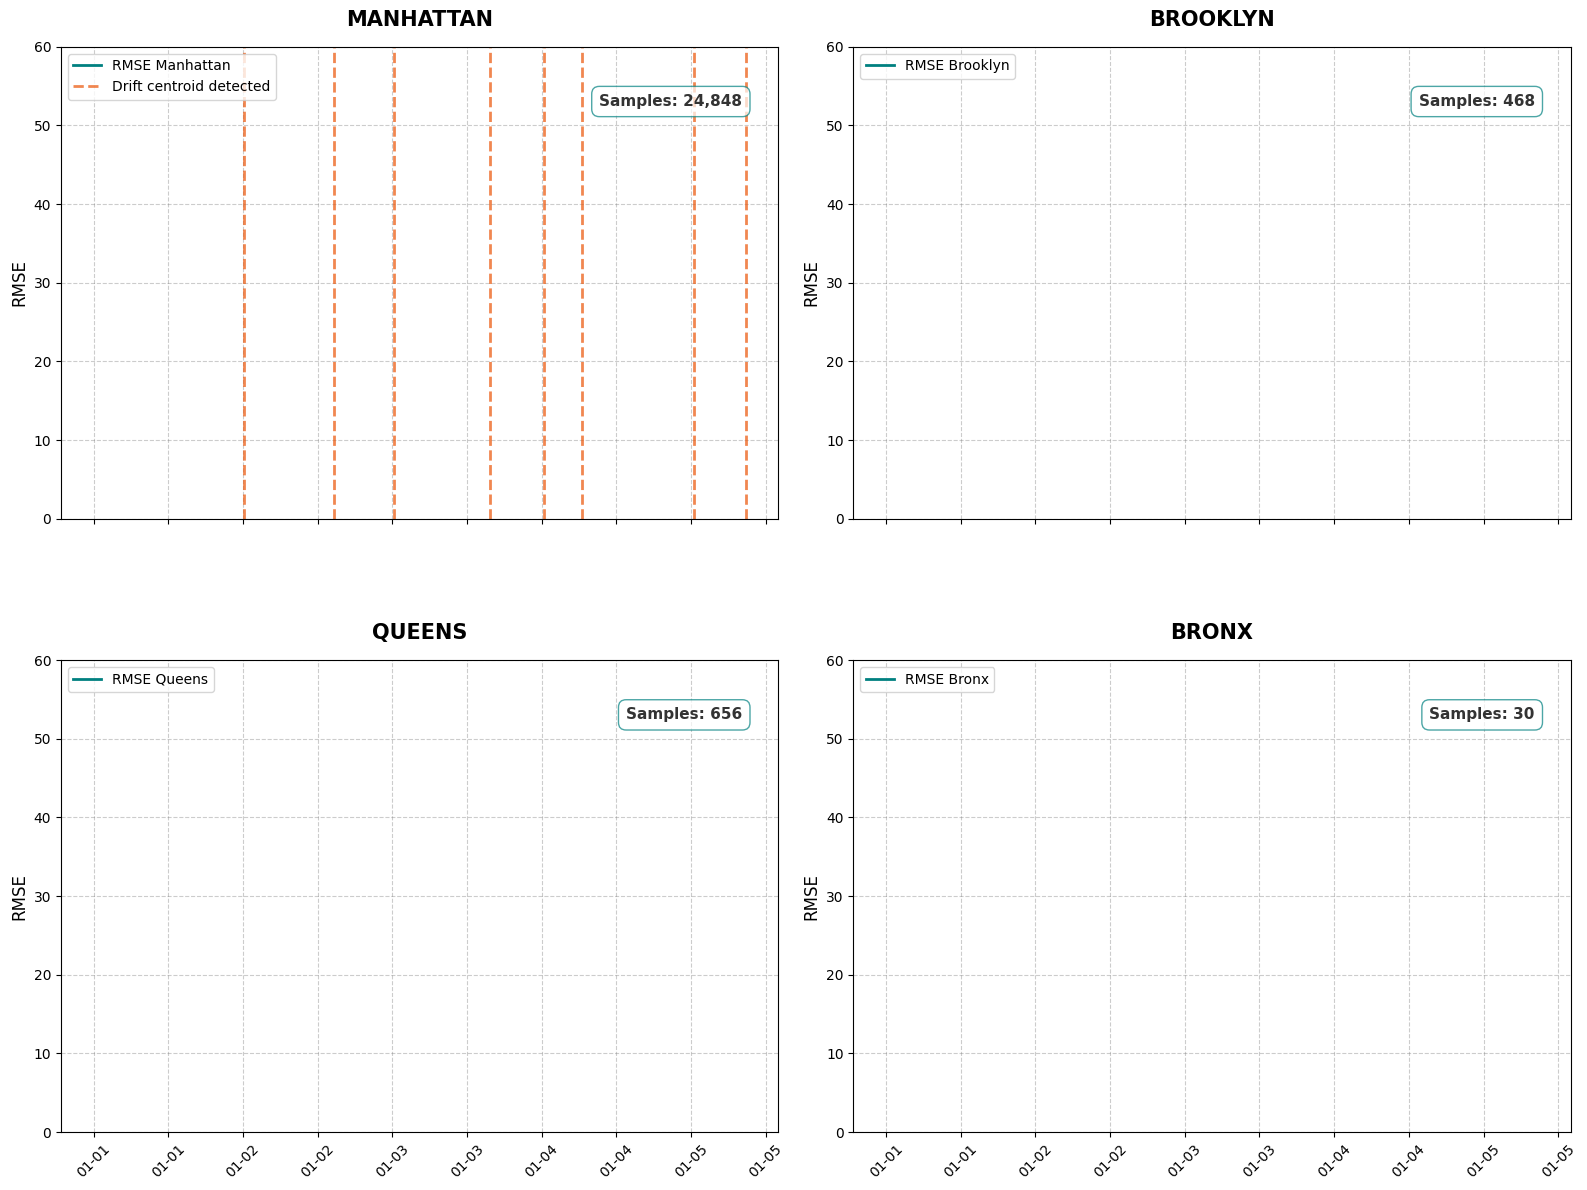

In [38]:

district_list = ["Manhattan", "Brooklyn", "Queens", "Bronx"]#Midwest
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for ax, dist in zip(axes, district_list):

    df = pd.DataFrame([
        (t, rmse)
        for t, values in window_rmse_series[dist].items()
        for rmse in values
    ], columns=["time", "rmse"])
    
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time")
    
    df_mean = df.groupby("time")["rmse"].mean()
    df_std = df.groupby("time")["rmse"].std()
    
    line_ref = ax.plot(
        df_mean.index,
        df_mean.values,
        color='#008080',
        linewidth=2,
        label=f"RMSE {dist}"
    )[0]


    color = line_ref.get_color()
    count = local_counts.get(dist, 0)

    ax.text(
        0.95, 0.90, f"Samples: {count:,}",
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='white',
                  alpha=0.7,
                  edgecolor=color),
        fontsize=11,
        fontweight='bold',
        color='#333333'
    )

    if dist in centroid_timestamps:
        for i, t in enumerate(centroid_timestamps[dist]):
            ax.axvline(
                pd.to_datetime(t),
                color="#EB5406",
                linestyle='--',
                linewidth=2,
                alpha=0.7,
                label="Drift centroid detected" if i == 0 else ""
            )

    # if dist in kswin_timestamps:
    #     for i, t in enumerate(kswin_timestamps[dist]):
    #         ax.axvline(
    #             pd.to_datetime(t),
    #             color="#FFE5B4",
    #             linestyle='--',
    #             linewidth=2,
    #             alpha=0.7,
    #             label="Distribution shift detected" if i == 0 else ""
    #         )

    ax.set_title(dist.upper(), fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel("RMSE", fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.4, color='gray')

    #ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    ax.tick_params(axis='x', rotation=45, labelsize=10)

    ax.legend(loc='upper left', frameon=True, facecolor='white')
    ax.set_ylim(0, 60)
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.savefig('Taxi.png', dpi=300, bbox_inches='tight')
plt.show()